<a href="https://colab.research.google.com/github/RabinPhuyal/Deep-Learning-with-Pytorch/blob/main/PyTorch_Computer__Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PyTorch Computer Vision**

In [2]:
#0. Import Libraries

In [3]:

#Import torch
import torch
from torch import nn

#Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

#Import matplotlib for visualization
import matplotlib.pyplot as plt

#Check version
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [4]:
#1 Getting a Dataset

In [5]:
# Setting up training data
train_data = datasets.FashionMNIST(
    root = "data", #Where to download the file
    train = True, #Whether training or testing set
    download = True, #Download the data
    transform = ToTensor(), #Converting PIL format to Pytorch tensor
    target_transform = None #You can perform transformation on label/target
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.70MB/s]


In [6]:
# Setting up testing set
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

In [7]:
# See first training sample
image, label = train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [8]:
#1.1 Input and Output shapes of a computer vision model

In [9]:
# What's the shape of the image?
image.shape

torch.Size([1, 28, 28])

In [10]:
# [color_channels= 1, height= 28, width= 28]
# Having 1 color chanel means grayscale
# If color_channels = 3 then it is a RGB color model
# Order of our current tensor is CHW (color_channels, height, width)
# NCHW (Number of images, Color Channels, Height, Width) -> Default for many operators
# NHWC (Number of images, Height, Width, Color Channesl) -> Better and best practice

In [11]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [12]:
# See classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

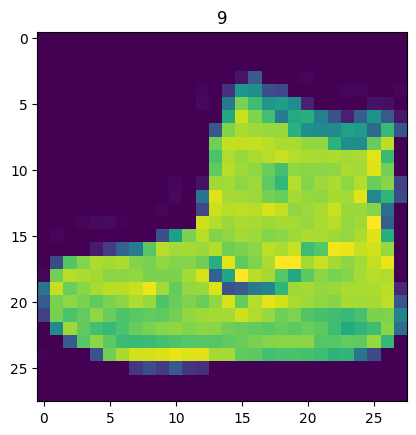

In [13]:
# Visualizing our data
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

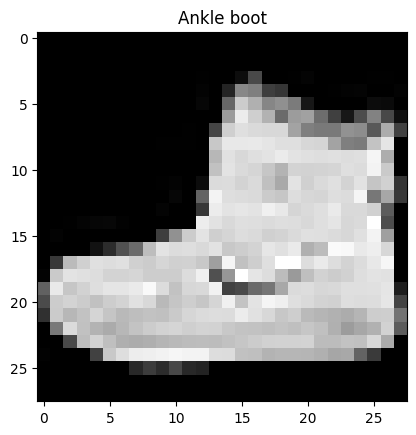

In [14]:
#Image in Grayscale
plt.imshow(image.squeeze(), cmap="grey")
plt.title(class_names[label])

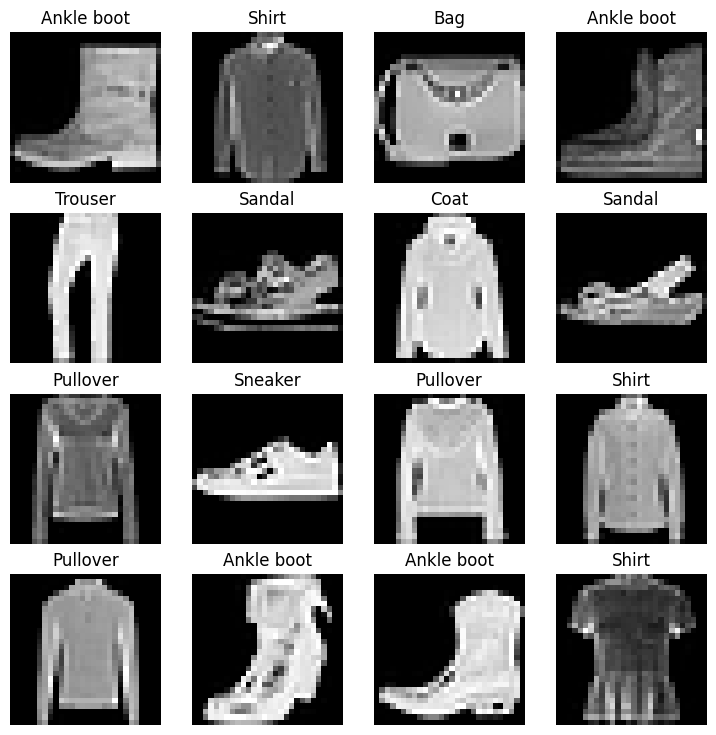

In [15]:
#plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data),size= [1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(), cmap="grey")
  plt.title(class_names[label])
  plt.axis(False)

In [16]:
#2. Prepare a DataLoader

from torch.utils.data import DataLoader

#Setting up the batch size
BATCH_SIZE = 32

#Turning datasets into iterable
train_dataloader = DataLoader(
    train_data,
    batch_size = BATCH_SIZE,
    shuffle= True
)

test_dataloader = DataLoader(
    test_data,
    batch_size= BATCH_SIZE,
    shuffle= False
)

#Let's check out what's we created
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length  of Train Dataloader: {len(train_dataloader)} of batch size {BATCH_SIZE}")
print(f"Length of Test Dataloader: {len(test_dataloader)} of batch size {BATCH_SIZE}")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7e4214f76e40>, <torch.utils.data.dataloader.DataLoader object at 0x7e42140d6490>)
Length  of Train Dataloader: 1875 of batch size 32
Length of Test Dataloader: 313 of batch size 32


In [17]:
# Check out what's inside the training datasets

train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 6 Label Size: torch.Size([])


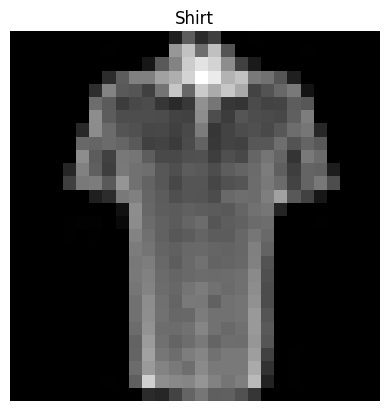

In [18]:
# Showing a sample

torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="grey")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size: {img.shape}")
print(f"Label: {label} Label Size: {label.shape}")

**Model 0: Build a Baseline Model**

In [19]:
# Create a flatten model
flatten_model = nn.Flatten()

# Getting a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x)

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")
# print(x)
# print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


In [20]:
#Build a model
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape:int, hidden_units: int, output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape, out_features= hidden_units),
        nn.Linear(in_features= hidden_units, out_features= output_shape)
    )

  def forward(self,x):
      return self.layer_stack(x)

In [21]:
#Let's instantiate the model
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape= 784,
    hidden_units= 10,
    output_shape= len(class_names)
)

model_0.to("cpu")

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [22]:
# Importing helper_functions.py

import requests
from pathlib import Path

# Downloads helper function from learn PyTorch repo

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exits, skipping content")

else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [23]:
# Import accuracy metrics
from helper_functions import accuracy_fn

# Setup loss function and optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_0.parameters(), lr=0.1)

In [24]:
# Creating a function to time our experiments

from timeit import default_timer as timer
def print_train_time(start:float, end:float, device:torch.device = None):

  """ Prints difference between start and end time
  Args:
  start(float) : Start time of computation
  end(float):  End time of computation
  device([type], optional): Device that compute is running on. Defaults to None

  Returns:
  float: time between start and end in seconds

  """
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [25]:
#3.3 Creating a training loop and training a model on batches of data

In [26]:
#Import tqdm for progress bar

from tqdm.auto import tqdm

#Set the seed and start the timer

torch.manual_seed(42)
train_time_start_on_cpu = timer()

#Set the timer of epochs
epochs = 3

#Create a training and testing loop

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------------")

  ###Training

  train_loss = 0
  #Add a loop to loop through training batches

  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()

    #1.Forward Pass
    y_pred = model_0(X)

    #2.Calculate loss (per batch)
    loss = loss_fn(y_pred,y)
    train_loss +=loss

    #3.Optimizer zero grad
    optimizer.zero_grad()

    #4.Loss Backwards
    loss.backward()

    #5.Optimizer step
    optimizer.step()

    #Print out how many samples have been seen
    if batch %400 ==0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

  #Divide the total train loss by the length of train dataloader
  train_loss /= len(train_dataloader)

  ###Testing

  model_0.eval()
  test_loss, test_acc = 0,0
  with torch.inference_mode():
    for X,y in test_dataloader:
      #1. Forward pass
      test_pred = model_0(X)

      #2. Calculate cumulative test loss
      test_loss += loss_fn(test_pred, y)

      #3. Calculate cumulative accuracy
      test_acc += accuracy_fn(
          y_true= y,
          y_pred= test_pred.argmax(dim=1)
      )

    test_loss /= len(test_dataloader)

    test_acc /= len(test_dataloader)

  print(f"\nTrain Loss: {train_loss:.5f} |"
  f"Test Loss: {test_loss:.5f} |"
  f"Test Accuracy: {test_acc:.2f}%\n")

#Calculate training time
train_time_end_on_cpu = timer()

total_train_time_model_0 = print_train_time(
    start= train_time_start_on_cpu,
    end= train_time_end_on_cpu,
    device= str(next(model_0.parameters()).device)
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train Loss: 0.59039 |Test Loss: 0.50954 |Test Accuracy: 82.04%

Epoch: 1
-------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train Loss: 0.47633 |Test Loss: 0.47989 |Test Accuracy: 83.20%

Epoch: 2
-------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train Loss: 0.45503 |Test Loss: 0.47664 |Test Accuracy: 83.43%

Train time on cpu: 29.977 seconds


In [27]:
#4. Make Predictions and get Model 0 results

torch.manual_seed(42)
def eval_model(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn):
  """
Return a dictionary containing the results of model_prediciting on data loader

Args:
model(torch.nn.Module): A Pytorch model capable of making predictions on datasets
data_loader(torch.utils.data.DataLoader): The target dataset to predict on
loss_fn(torch.nn.Module): The loss function of model
accuracy_fn: An accuracy function to compare the models prediction on the truth labels

Return:
(dict): Results of model making predictions on data_loader

"""
  loss,acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      #1. Predicting with the model
      y_pred = model(X)

      #2. Accumulate the loss and accuracy per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(
          y_true=y,
          y_pred= y_pred.argmax(dim=1)
      )

    #Scale loss and acc to find the average loss/acc per batch

    loss/= len(data_loader)
    acc/= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss.item(),
        "model_acc": acc
    }

#Calculate model 0 results on test dataloader

model_0_results = eval_model(
    model= model_0,
    data_loader= test_dataloader,
    loss_fn= loss_fn,
    accuracy_fn= accuracy_fn
)

model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [28]:
# Setup device agnostic code

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

**Model 1: Building a better model with non-linearity**

In [29]:
# Create a model with linear and non linear layer

class FashionMNISTModelV1(nn.Module):
  def __init__(
      self,
      input_shape:int,
      hidden_units:int,
      output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape, out_features= hidden_units),
        nn.ReLU(),
        nn.Linear(in_features= hidden_units,out_features= output_shape),
        nn.ReLU()
    )
  def forward(self,x):
    return self.layer_stack(x)

In [30]:
# Model Initialization
torch.manual_seed(42)

model_1 = FashionMNISTModelV1(
    input_shape= 784,
    hidden_units= 10,
    output_shape= len(class_names)
).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

In [31]:
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [32]:
# 6.1 Setup loss function and optimizer
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params= model_1.parameters(),lr=0.1)

In [33]:
#6.2 Functionizing training and test loops

def train_step(
    model:torch.nn.Module,
    data_loader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    optimizer:torch.optim.Optimizer,
    accuracy_fn,
    device:torch.device=device):
  train_loss, train_acc =0,0
  model.to(device)

  for batch, (X,y) in enumerate(data_loader):
    #Sent the data to GPU
    X,y = X.to(device),y.to(device)

    #1. Forward Pass
    y_pred = model(X)

    #2. Calculate loss
    loss = loss_fn(y_pred,y)
    train_loss += loss
    train_acc += accuracy_fn(
        y_true= y,
        y_pred = y_pred.argmax(dim=1)
    )

    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Loss backwards
    loss.backward()

    #5. Step optimizer
    optimizer.step()

#Calculate train loss and accuracy per epoch and print out what's happening
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train Loss: {train_loss:.5f} | Train Accuracy:{train_acc:.2f}%")

def test_step(
    model:torch.nn.Module,
    data_loader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    accuracy_fn,
    device:torch.device=device):
  test_loss,test_acc= 0,0
  #Sent the model to GPU
  model.to(device)

  #Set the model in evaluation mode
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      #Sent data to GPU
      X,y = X.to(device), y.to(device)

      #1. Forward Pass
      test_pred = model(X)

      #2. Calculate loss
      loss = loss_fn(test_pred,y)
      test_loss += loss
      test_acc += accuracy_fn(
        y_true= y,
        y_pred= test_pred.argmax(dim=1)
      )

    #Calculate test loss and accuracy per epochs and print out what's happening
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

In [34]:
# Time to run on the GPU

torch.manual_seed(42)

#Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

#Set the number of epochs
epochs = 3

for epoch in range(epochs):
  print(f"Epoch: {epoch}\n-------------------")
  train_step(
      model=model_1,
      data_loader=train_dataloader,
      loss_fn= loss_fn,
      accuracy_fn=accuracy_fn,
      optimizer=optimizer
  )
  test_step(
      model=model_1,
      data_loader=test_dataloader,
      loss_fn=loss_fn,
      accuracy_fn=accuracy_fn
  )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(
    start=train_time_start_on_gpu,
    end=train_time_end_on_gpu,
    device=device
)

Epoch: 0
-------------------
Train Loss: 1.09199 | Train Accuracy:61.34%
Test Loss: 0.95636 | Test Accuracy: 65.00%
Epoch: 1
-------------------
Train Loss: 0.78101 | Train Accuracy:71.93%
Test Loss: 0.72227 | Test Accuracy: 73.91%
Epoch: 2
-------------------
Train Loss: 0.67027 | Train Accuracy:75.94%
Test Loss: 0.68500 | Test Accuracy: 75.02%
Train time on cuda: 34.333 seconds


In [35]:
# Move values to device
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1 results with device-agnostic code
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [36]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

 **Model 2: Building a Convolutional Neural Network (CNN)**

In [37]:
# Create a Convolutional Neural Network
class FashionMNISTModelV2(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()

    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )

    self.block_2= nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
        nn.ReLU(),
        nn.Conv2d(hidden_units,hidden_units,3,1,1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=hidden_units*7*7,
            out_features= output_shape)
    )
  def forward(self, x:torch.Tensor):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x

model_2 = FashionMNISTModelV2(
    input_shape = 1,
    hidden_units = 10,
    output_shape=len(class_names)).to(device)

model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [38]:
#Stepping through nn.Conv2d()
torch.manual_seed(42)

#Create sample batch random numbers with same size or image batch
images = torch.randn(size=(32,3,64,64))

test_image = images[0]

print(f"Image Batch Shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single Image Shape: {test_image.shape} -> [color_channels, height, width]")

print(f"Single Image Pixel Values: \n{test_image}")

Image Batch Shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single Image Shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single Image Pixel Values: 
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609

In [39]:
# Example of changing the hyperparameters of Convolutional layer
torch.manual_seed(42)

conv_layer = nn.Conv2d(
    in_channels= 3,
    out_channels = 10,
    kernel_size= 3,
    stride=1,
    padding=0
)

conv_layer(test_image)

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

In [40]:
# Add extra dimension to test image
test_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [41]:
# Pass test image with extra dimension through conv_layer
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

In [42]:
#Changing the value of convolutional layer

torch.manual_seed(42)

conv_layer_2 = nn.Conv2d(in_channels=3,
                         out_channels=10,
                         kernel_size=(5,5),
                         stride=2,
                         padding=0)

conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

In [43]:
#Check out the conv_layer_2 internal parameters

print(conv_layer_2.state_dict())

OrderedDict({'weight': tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
          [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
          [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
          [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
          [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],

         [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
          [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
          [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
          [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
          [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],

         [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
          [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
          [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
          [-0.0241,  0.0958, -0.0684, -0.0689, -0.0689],
          [ 0.1039,  0.0385,  0.1111, -0.0953, -0.1145]]],


        [[[-0.0903, -0.0777,  0.0468,  0.0413,  0.0959],
          [-0.0596, -0.0787,  0.0613, -0.0467,  0.0701],


In [44]:
#Get shapes of weight and bias tensors within conv_layer_2
print(f"conv_layer_2 weight shape:\n{conv_layer_2.weight.shape} -> [in_channels=3,out_channels =10,kernel_size= 5, kernel_size=5]")

print(f"conv_layer_2 bias shape:\n{conv_layer_2.bias.shape} -> [out_channels = 10]")

conv_layer_2 weight shape:
torch.Size([10, 3, 5, 5]) -> [in_channels=3,out_channels =10,kernel_size= 5, kernel_size=5]
conv_layer_2 bias shape:
torch.Size([10]) -> [out_channels = 10]


In [45]:
#7.2 Stepping through nn.MaxPool2d()

#Print out original image shape without and with unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqeeuzed dimensions: {test_image.unsqueeze(dim=0).shape}")
max_pool_layer = nn.MaxPool2d(kernel_size=2)

#Pass data through just the conv_layer

test_image_through_conv_layer = conv_layer(test_image.unsqueeze(dim=0))

print(f"Shape after going through conv_layer(): {test_image_through_conv_layer.shape}")

#Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv_layer)

print(f"Shape after going through conv_layer() and max_pool_layer():"
f"{test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqeeuzed dimensions: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer():torch.Size([1, 10, 31, 31])


In [46]:
torch.manual_seed(42)

#Create a random tensor with a similar number of dimensions to our images
random_tensor = torch.randn(size=(1,1,2,2))
print(f"Random tensor:\n{random_tensor}")
print(f"Random tensor shape:{random_tensor.shape}")

#Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

#Pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)

print(f"\nMaxPool tensor:\n{max_pool_tensor} <- maximum value of random_tensor")
print(f"\nMaxPool tensor shape:{max_pool_tensor.shape}")

Random tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape:torch.Size([1, 1, 2, 2])

MaxPool tensor:
tensor([[[[0.3367]]]]) <- maximum value of random_tensor

MaxPool tensor shape:torch.Size([1, 1, 1, 1])


In [47]:
#Set up loss function and optimizer for model_2

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_2.parameters(), lr=0.1)

In [48]:
#Training and testing model_2 using our training and test functions

torch.manual_seed(42)

#Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

#Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(
      data_loader=train_dataloader,
      model= model_2,
      loss_fn=loss_fn,
      optimizer= optimizer,
      accuracy_fn=accuracy_fn,
      device = device
  )
  test_step(
      data_loader= test_dataloader,
      model= model_2,
      accuracy_fn= accuracy_fn,
      loss_fn= loss_fn,
      device=device
  )

train_time_end_model_2 =timer()
total_train_time_model_2 = print_train_time(
    start= train_time_start_model_2,
    end= train_time_end_model_2,
    device=device
)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train Loss: 0.92106 | Train Accuracy:66.03%
Test Loss: 0.43649 | Test Accuracy: 84.47%
Epoch: 1
---------
Train Loss: 0.39208 | Train Accuracy:85.72%
Test Loss: 0.36000 | Test Accuracy: 86.66%
Epoch: 2
---------
Train Loss: 0.34028 | Train Accuracy:87.67%
Test Loss: 0.33927 | Test Accuracy: 87.67%
Train time on cuda: 41.019 seconds


In [49]:
#Get model_2 results
model_2_results = eval_model(
    model= model_2,
    data_loader=test_dataloader,
    loss_fn= loss_fn,
    accuracy_fn= accuracy_fn
)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3392651677131653,
 'model_acc': 87.66972843450479}

In [50]:
#8. Compare model results and training time

import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.339265,87.669728


In [51]:
#Add training times to results comparision
compare_results["training_time"] =[total_train_time_model_0,
                                   total_train_time_model_1,
                                   total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,29.977142
1,FashionMNISTModelV1,0.685001,75.019968,34.332766
2,FashionMNISTModelV2,0.339265,87.669728,41.018651


Text(0, 0.5, 'model')

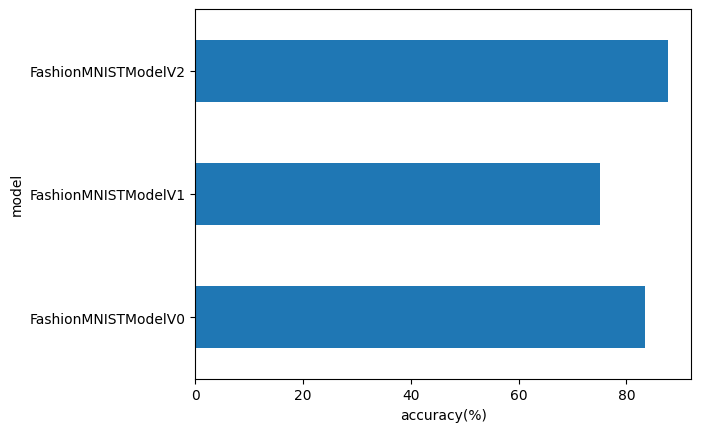

In [52]:
#Visualize our model_results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy(%)")
plt.ylabel("model")

In [53]:
#Make and evaluate random predictions with test model

def make_predictions(model:torch.nn.Module, data:list, device:torch.device= device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      #Prepare sample
      sample = torch.unsqueeze(sample,dim=0).to(device)

      pred_logit= model(sample)

      pred_prob = torch.softmax(pred_logit.squeeze(),dim=0)

      pred_probs.append(pred_prob.cpu())
  return torch.stack(pred_probs)

In [54]:
import random
random.seed(42)
test_samples=[]
test_labels=[]

for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)

print(f"Test sample image shape:{test_samples[0].shape}\nTest sample label:{test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape:torch.Size([1, 28, 28])
Test sample label:5 (Sandal)


In [55]:
#Make predictions on test samples with model_2
pred_probs= make_predictions(model=model_2, data=test_samples)

pred_probs[:2]

tensor([[2.0258e-07, 1.5536e-09, 1.0558e-08, 1.8242e-08, 4.7321e-09, 9.9981e-01,
         8.2546e-07, 1.9374e-05, 8.7786e-06, 1.6370e-04],
        [4.4725e-02, 6.2769e-01, 1.8919e-03, 2.7545e-01, 2.4379e-02, 4.9730e-04,
         2.0997e-02, 2.9057e-03, 4.7621e-04, 9.9146e-04]])

In [56]:
#Turn the prediction probabilities into prediction labels by taking the argmax
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [57]:
#Are our predictions in the same form as test labels?

test_labels,pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

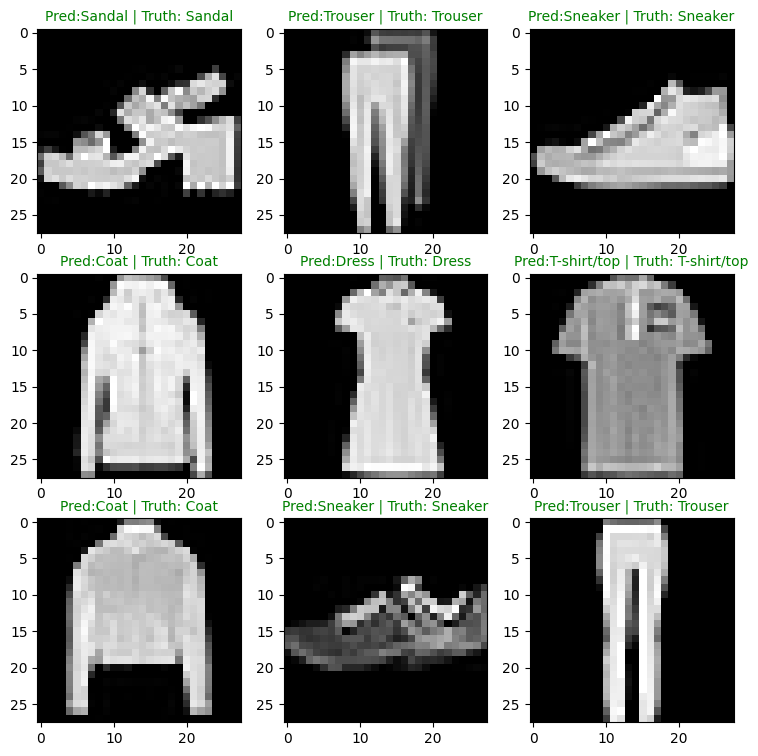

In [58]:
#Plot Predictions
plt.figure(figsize=(9,9))
nrows= 3
ncols= 3
for i,sample in enumerate(test_samples):
  #Create a subplot
  plt.subplot(nrows,ncols,i+1)

  #Plot the target image
  plt.imshow(sample.squeeze(),cmap="gray")

  #Find the prediction label
  pred_label = class_names[pred_classes[i]]

  #Get the truth label
  truth_label= class_names[test_labels[i]]

  #Create the title test of the plot
  title_text= f"Pred:{pred_label} | Truth: {truth_label}"

  #Check for equality and change title color
  if pred_label == truth_label :
    plt.title(title_text,fontsize=10, c="g")
  else:
    plt.title(title_text, fontsize=10, c="r")

In [59]:
#Making a confusion matrix for future predictions

In [60]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

In [62]:
#Saving and loading the best model
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_2.pth
